## Running initial PSF modeling with LSST Science Pipelines

## Get the simulated star field from Erin Sheldon

In [ ]:
! wget https://www.cosmo.bnl.gov/www/esheldon/data/tmp/00001319.tar

In [4]:
! mv 00001319.tar ~/

In [7]:
! tar -xvf /home/k/kannawad/00001319.tar

00001319/
00001319/instcat.txt
00001319/simdata-00001319-0-g-R03_S01-det019.fits
00001319/piff-00001319-0-g-R03_S01-det019.pkl
00001319/source-00001319-0-g-R03_S01-det019.fits


## Read in and repackage the image

In [2]:
import galsim
import os
galim = galsim.fits.read(f"/home/k/{os.environ['USER']}/notebooks/00001319/simdata-00001319-0-g-R03_S01-det019.fits", hdu=0)
array = galim.array

In [3]:
true_background = galsim.fits.read(f"/home/k/{os.environ['USER']}/notebooks/00001319/simdata-00001319-0-g-R03_S01-det019.fits", hdu=1)

## Interpreting the image

In [55]:
from lsst.afw.geom import makeSkyWcs

def galsim_wcs_to_dm_wcs(gwcs):
    cdMatrix = gwcs.cd
    crPix = lsst.geom.Point2D(gwcs.crpix)
    crVal = lsst.geom.SpherePoint(gwcs.center.galactic()[0].deg, gwcs.center.galactic()[1].deg, lsst.geom.degrees)

    return makeSkyWcs(crpix=crPix, crval=crVal, cdMatrix=cdMatrix)

In [56]:
import lsst.afw.image as afwImage
import lsst.geom

extent = lsst.geom.Extent2I(array.shape[1], array.shape[0])
postISRCCD = afwImage.ExposureF(afwImage.MaskedImageF(image=afwImage.ImageF(dimensions=extent), mask=afwImage.Mask(dimensions=extent), variance=afwImage.ImageF(dimensions=extent)))
postISRCCD.image.array[:, :] = array
postISRCCD.variance.array[:, :] = 200 # array


postISRCCD.setWcs(galsim_wcs_to_dm_wcs(galim.wcs))

Visualize the image before it gets modified in-place.

In [7]:
from lsst.afw.display import Display
disp = Display(frame=1, backend='firefly')
disp.scale("linear", "zscale")
disp.mtv(postISRCCD)

Take a look at the current DRP pipeline at

https://tigress-web.princeton.edu/~lkelvin/pipelines/current/drp_pipe/LSSTCam/DRP/pipeline_drp_pipe_LSSTCam_DRP.pdf

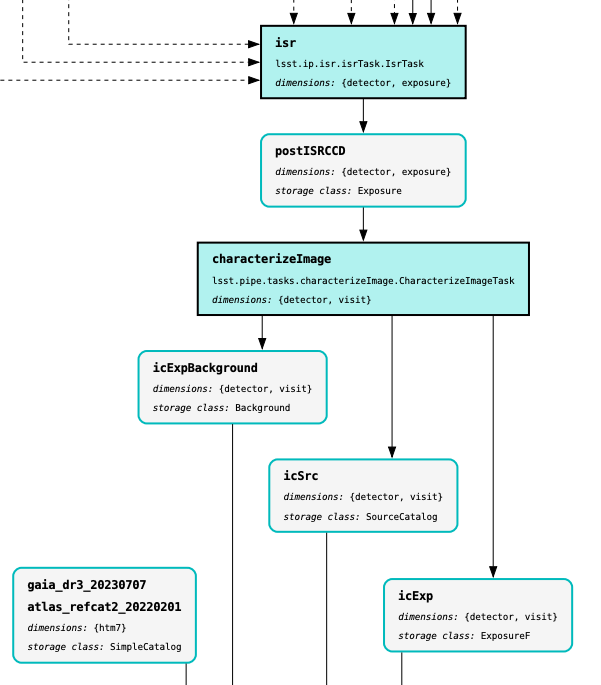

Since ISR was not simulated, we will assume this is equivalent to an ISR-corrected (perfectly at that one) and treat it as a `postISRCCD` and run `CharacterizeImageTask`.

In [1]:
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask

import lsst.meas.extensions.piff.piffPsfDeterminer
import lsst.meas.extensions.shapeHSM

## Configure `CharacterizeImageTask`

By default, it runs `PSFEx`. Configure it explicitly to run `piff`.

In [30]:
config = CharacterizeImageTask.ConfigClass()
config.measurePsf.psfDeterminer = "piff"
config.measurePsf.psfDeterminer["piff"].debugStarData = True
config.measurePsf.reserve.fraction = 0.2
config.measurePsf.psfDeterminer['piff'].maxSNR = 100.
config.measurement.plugins.names |= ["ext_shapeHSM_HsmSourceMoments", "ext_shapeHSM_HsmPsfMoments", "base_SdssShape"]

config.measurement.slots.shape = "ext_shapeHSM_HsmSourceMoments"
config.measurement.slots.psfShape = "ext_shapeHSM_HsmPsfMoments"

#### See the full set of config values
Warning: It is long

In [235]:
from pprint import pprint
pprint(config.toDict())

{'applyApCorr': {'doFlagApCorrFailures': True, 'ignoreList': [], 'proxies': {}},
 'background': {'algorithm': 'AKIMA_SPLINE',
                'approxOrderX': 6,
                'approxOrderY': -1,
                'binSize': 128,
                'binSizeX': 0,
                'binSizeY': 0,
                'ignoredPixelMask': ['BAD',
                                     'EDGE',
                                     'DETECTED',
                                     'DETECTED_NEGATIVE',
                                     'NO_DATA'],
                'isNanSafe': False,
                'statisticsProperty': 'MEANCLIP',
                'undersampleStyle': 'REDUCE_INTERP_ORDER',
                'useApprox': True,
                'weighting': True},
 'catalogCalculation': {'plugins': {'names': ['base_ClassificationExtendedness', 'base_FootprintArea'],
                                    'values': {'base_ClassificationExtendedness': {'fluxRatio': 0.95,
                                          

#### Initialize the CharacterizeImageTask and run it on the image

In [34]:
task = CharacterizeImageTask(config=config)

In [38]:
ret = task.run(postISRCCD)

### Inspecting the catalog

#### Check out the schema

In [189]:
ret.sourceCat.schema

Schema(
    (Field['L'](name="id", doc="unique ID"), Key<L>(offset=0, nElements=1)),
    (Field['Angle'](name="coord_ra", doc="position in ra/dec"), Key<Angle>(offset=8, nElements=1)),
    (Field['Angle'](name="coord_dec", doc="position in ra/dec"), Key<Angle>(offset=16, nElements=1)),
    (Field['L'](name="parent", doc="unique ID of parent source"), Key<L>(offset=24, nElements=1)),
    (Field['Flag'](name="calib_psf_candidate", doc="Flag set if the source was a candidate for PSF determination, as determined by the star selector."), Key['Flag'](offset=32, bit=0)),
    (Field['Flag'](name="calib_psf_used", doc="Flag set if the source was actually used for PSF determination, as determined by the 'piff' PSF determiner."), Key['Flag'](offset=32, bit=1)),
    (Field['Flag'](name="calib_psf_reserved", doc="set if source was reserved from PSF determination"), Key['Flag'](offset=32, bit=2)),
    (Field['D'](name="base_SdssCentroid_x", doc="centroid from Sdss Centroid algorithm", units="pixel")

#### Check out the catalog

In [185]:
ret.sourceCat.asAstropy()

id,coord_ra,coord_dec,parent,calib_psf_candidate,calib_psf_used,calib_psf_reserved,base_SdssCentroid_x,slot_Centroid_x,base_SdssCentroid_y,slot_Centroid_y,base_SdssCentroid_xErr,slot_Centroid_xErr,base_SdssCentroid_yErr,slot_Centroid_yErr,base_SdssCentroid_flag,base_CircularApertureFlux_flag_badCentroid,base_GaussianFlux_flag_badCentroid,base_PsfFlux_flag_badCentroid,base_SdssShape_flag_badCentroid,ext_shapeHSM_HsmPsfMoments_flag_badCentroid,ext_shapeHSM_HsmSourceMoments_flag_badCentroid,slot_Centroid_flag,base_SdssCentroid_flag_edge,base_CircularApertureFlux_flag_badCentroid_edge,base_GaussianFlux_flag_badCentroid_edge,base_PsfFlux_flag_badCentroid_edge,base_SdssShape_flag_badCentroid_edge,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_edge,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_edge,slot_Centroid_flag_edge,base_SdssCentroid_flag_noSecondDerivative,base_CircularApertureFlux_flag_badCentroid_noSecondDerivative,base_GaussianFlux_flag_badCentroid_noSecondDerivative,base_PsfFlux_flag_badCentroid_noSecondDerivative,base_SdssShape_flag_badCentroid_noSecondDerivative,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_noSecondDerivative,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_noSecondDerivative,slot_Centroid_flag_noSecondDerivative,base_SdssCentroid_flag_almostNoSecondDerivative,base_CircularApertureFlux_flag_badCentroid_almostNoSecondDerivative,base_GaussianFlux_flag_badCentroid_almostNoSecondDerivative,base_PsfFlux_flag_badCentroid_almostNoSecondDerivative,base_SdssShape_flag_badCentroid_almostNoSecondDerivative,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_almostNoSecondDerivative,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_almostNoSecondDerivative,slot_Centroid_flag_almostNoSecondDerivative,base_SdssCentroid_flag_notAtMaximum,base_CircularApertureFlux_flag_badCentroid_notAtMaximum,base_GaussianFlux_flag_badCentroid_notAtMaximum,base_PsfFlux_flag_badCentroid_notAtMaximum,base_SdssShape_flag_badCentroid_notAtMaximum,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_notAtMaximum,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_notAtMaximum,slot_Centroid_flag_notAtMaximum,base_SdssCentroid_flag_near_edge,base_CircularApertureFlux_flag_badCentroid_near_edge,base_GaussianFlux_flag_badCentroid_near_edge,base_PsfFlux_flag_badCentroid_near_edge,base_SdssShape_flag_badCentroid_near_edge,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_near_edge,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_near_edge,slot_Centroid_flag_near_edge,base_SdssCentroid_flag_resetToPeak,base_CircularApertureFlux_flag_badCentroid_resetToPeak,base_GaussianFlux_flag_badCentroid_resetToPeak,base_PsfFlux_flag_badCentroid_resetToPeak,base_SdssShape_flag_badCentroid_resetToPeak,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_resetToPeak,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_resetToPeak,slot_Centroid_flag_resetToPeak,base_SdssCentroid_flag_badError,base_CircularApertureFlux_flag_badCentroid_badError,base_GaussianFlux_flag_badCentroid_badError,base_PsfFlux_flag_badCentroid_badError,base_SdssShape_flag_badCentroid_badError,ext_shapeHSM_HsmPsfMoments_flag_badCentroid_badError,ext_shapeHSM_HsmSourceMoments_flag_badCentroid_badError,slot_Centroid_flag_badError,base_SdssShape_xx,base_SdssShape_yy,base_SdssShape_xy,base_SdssShape_xxErr,base_SdssShape_yyErr,base_SdssShape_xyErr,base_SdssShape_x,base_SdssShape_y,base_SdssShape_instFlux,base_SdssShape_instFluxErr,base_SdssShape_psf_xx,base_SdssShape_psf_yy,base_SdssShape_psf_xy,base_SdssShape_instFlux_xx_Cov,base_SdssShape_instFlux_yy_Cov,base_SdssShape_instFlux_xy_Cov,base_SdssShape_flag,base_SdssShape_flag_unweightedBad,base_SdssShape_flag_unweighted,base_SdssShape_flag_shift,base_SdssShape_flag_maxIter,base_SdssShape_flag_psf,ext_shapeHSM_HsmPsfMoments_flag,slot_PsfShape_flag,ext_shapeHSM_HsmPsfMoments_flag_no_pixels,slot_PsfShape_flag_no_pixels,ext_shapeHSM_HsmPsfMoments_flag_not_contained,slot_PsfShape_flag_not_contained,ext_shapeHSM_HsmPsfMoments_flag_parent_source,slot_PsfShape_flag_parent_source,ext_shapeHSM_HsmPsfMoments_fl

#### Calculate some basic statistics

How many detections?

In [39]:
len(ret.sourceCat)

211

What fraction of them are classified (incorrectly) as extended objects (galaxies)?

In [40]:
import numpy as np
print(100*np.nanmean(ret.sourceCat['base_ClassificationExtendedness_value']), "%")

0.0 %


How many stars were candidates for PSF modelling?

In [41]:
ret.sourceCat['calib_psf_candidate'].sum()

187

How many stars were used for PSF modelling?

In [42]:
ret.sourceCat['calib_psf_used'].sum()

150

What fraction of them are reserved?

In [45]:
ret.sourceCat['calib_psf_reserved'].mean()

0.17535545023696683

### Look at the 'characterized' image

In [44]:
from lsst.afw.display import Display
disp2 = Display(frame=2, backend='firefly')
disp2.mtv(ret.characterized)
disp2.centroids(ret.sourceCat)

## Do some analysis

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [59]:
PIXEL_SCALE = 0.2

T = (ret.sourceCat["ext_shapeHSM_HsmSourceMoments_xx"] + ret.sourceCat["ext_shapeHSM_HsmSourceMoments_yy"])*PIXEL_SCALE**2
T_sdss = (ret.sourceCat["base_SdssShape_xx"] + ret.sourceCat["base_SdssShape_yy"])*PIXEL_SCALE**2
T_psf = (ret.sourceCat["ext_shapeHSM_HsmPsfMoments_xx"] + ret.sourceCat["ext_shapeHSM_HsmPsfMoments_yy"])*PIXEL_SCALE**2

mag = 30 -2.5*np.log10(ret.sourceCat["base_PsfFlux_instFlux"])

/tmp/ipykernel_2887/97700466.py:6: RuntimeWarning: invalid value encountered in log10
  mag = 30 -2.5*np.log10(ret.sourceCat["base_PsfFlux_instFlux"])


In [60]:
cut_psf_stars = (ret.sourceCat["calib_psf_used"] == 1)
cut_stars = (ret.sourceCat["base_ClassificationExtendedness_value"] == 0)

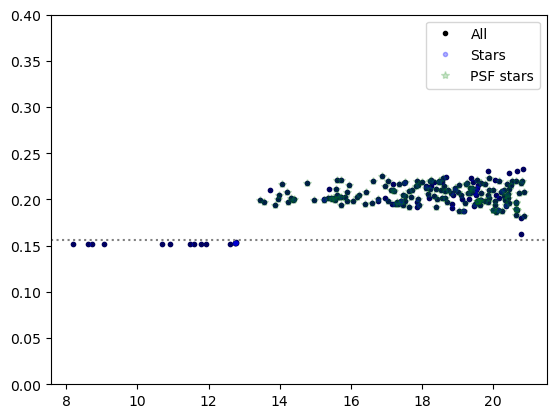

In [49]:
plt.plot(mag, T, 'k.', label="All")
plt.plot(mag[cut_stars], T[cut_stars], 'b.', alpha=0.3, label="Stars")
plt.plot(mag[cut_psf_stars], T[cut_psf_stars], 'g*', alpha=0.2, label="PSF stars")
#plt.plot(mag, T_psf, 'ko', alpha=0.1)
#plt.plot(mag, T_sdss, 'ks', alpha=0.05)
plt.axhline(3.9*0.2*0.2, ls=':', color='gray')
plt.ylim([0.0, 0.4])
plt.legend(loc="best")
#plt.yscale("log")

What are those small, bright objects? Let's locate them.

In [61]:
cut_toosmall = (T < 4.5*PIXEL_SCALE**2)
disp2.centroids(ret.sourceCat[cut_toosmall], symbol='x')

## General considerations

- We want to test the *as-built* system
- Use extreme caution in treating the stack as a typical library
- Identify a simulated image with a dataset type (see pipelines diagram)
- Use high-level Tasks and Configs to interact with the stack whenever possible
    - Configs are pretty much the only part where we offer stability and follow deprecation procedures
    - Adding missing features and contributing (e.g., `modelSize` field in `meas_extensions_piff` is extremely useful)
- Get all plotting tools into `analysis_tools`. There'll be limited opportunities to make such plots after commissioning.
- Use USDF/Rubin Science Platform whenever possible.

#### Ugly stuff that you don't want to see

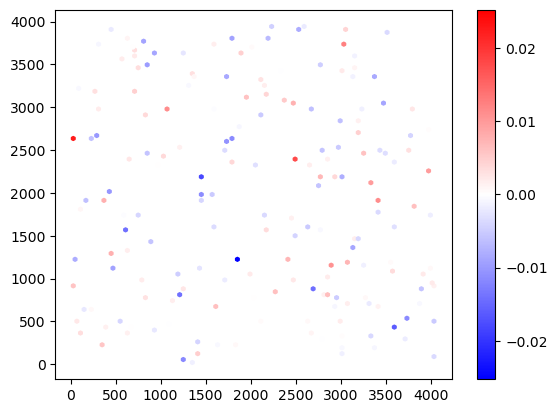

In [328]:
v = np.nanmax(np.abs(T-T_psf)[cut_psf_stars])
im = plt.hexbin(ret.sourceCat.getX()[cut_psf_stars], ret.sourceCat.getY()[cut_psf_stars], (T-T_psf)[cut_psf_stars], cmap=cm.bwr, vmin=-v, vmax=v)
plt.colorbar(im)

In [301]:
psf = ret.characterized.psf

In [306]:
psf.piffResult.model

2.5954736702157115

In [312]:
pprint(config.measurePsf.psfDeterminer["piff"].toDict())

{'debugStarData': False,
 'downsampleRandomSeed': 98765,
 'interpolant': 'Lanczos(11)',
 'maxCandidates': 300,
 'maxSNR': 200.0,
 'minimumUnmaskedFraction': 0.5,
 'modelSize': 25,
 'outlierMaxRemove': 0.05,
 'outlierNSigma': 4.0,
 'piffLoggingLevel': 0,
 'samplingSize': 1.0,
 'spatialOrder': 2,
 'stampSize': 25,
 'useCoordinates': 'pixel',
 'zeroWeightMaskBits': ['BAD', 'CR', 'INTRP', 'SAT', 'SUSPECT', 'NO_DATA']}


In [329]:
! wc -l 00001319/instcat.txt

205246 00001319/instcat.txt


In [330]:
import piff

In [338]:
star = psf.piffResult.stars[0]

In [343]:
star.u, star.v

(272.4741505477166, 4.165800679627765)

In [348]:
piff.StarFit?

Init signature:
piff.StarFit(
    params,
    flux=1.0,
    center=(0.0, 0.0),
    params_var=None,
    A=None,
    b=None,
    chisq=None,
    dof=None,
)
Docstring:     
Class to hold the results of fitting a Model to some StarData, or specify
the PSF interpolated to an unmeasured location.

**Class is intended to be invariant once created.**

This class can be extended
to carry information of use to a given Model instance (such as intermediate
results), but interpolators will be looking for some subset of these properties:

:params:      numpy array of parameters of the PSF that apply to this star
:params_var:  numpy array of variance error parameters of the PSF
:flux:        flux of the star
:center:      (u,v) tuple giving position of stellar center (relative
              to data.image_pos)
:chisq:       Chi-squared of  fit to the data (if any) with current params
:dof:         Degrees of freedom in the fit (will depend on whether last fit had
              parameters free or jus

In [20]:
len(mag), np.nanmax(mag), (~np.isnan(mag)).sum()

(211, 20.87460834617287, 210)

In [24]:
import yaml
with open("00001319/config.yaml") as fp:
    piff_config = yaml.safe_load(fp)

In [25]:
import piff
piff.piffify(piff_config)

Getting wcs from image file 00001319/simdata-00001319-0-g-R03_S01-det019.fits


Reading image file 00001319/simdata-00001319-0-g-R03_S01-det019.fits


Reading input catalog 00001319/source-00001319-0-g-R03_S01-det019.fits.


Object at position 3435.391113,14.250313 overlaps the edge of the image.


Skipping this object.


...

Iteration 7: Fitting 52 stars


             Total chisq = 7473.98 / 59878 dof


Iteration 8: Fitting 49 stars


             Total chisq = 7364.58 / 59878 dof


Writing PSF to file 00001319/output.piff
